# Notebook 2 — Retrieval Evaluation

Evaluates bi-encoder retrieval quality across TOP_K ∈ {1, 2, 4} using the 20 labelled alerts.

Metrics:
- **Precision@K** — of K retrieved, how many are correct?
- **Recall@K** — of all correct, how many were retrieved?
- **MRR** — Mean Reciprocal Rank of first correct hit
- **Hit Rate@K** — fraction of queries with ≥1 correct hit

Produces comparison bar charts saved to `eval/`.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import chromadb
import matplotlib.pyplot as plt
import numpy as np
import rag
from eval.evaluate import precision_at_k, recall_at_k, reciprocal_rank

client = chromadb.PersistentClient(path='../chroma_store')
collection = client.get_collection(rag.COLLECTION)

with open('../eval/labelled_alerts.json') as f:
    labels = json.load(f)

print(f'{len(labels)} labelled test alerts loaded')

20 labelled test alerts loaded


In [2]:
def run_eval(top_k, labels, collection):
    ps, rs, rrs, hits = [], [], [], []
    for s in labels:
        retrieved = [h['id'] for h in rag.retrieve(s['alert'], collection, top_k=top_k)]
        relevant  = s['ground_truth_playbook_ids']
        ps.append(precision_at_k(retrieved, relevant))
        rs.append(recall_at_k(retrieved, relevant))
        rr = reciprocal_rank(retrieved, relevant)
        rrs.append(rr)
        hits.append(1 if rr > 0 else 0)
    n = len(labels)
    return {
        f'P@{top_k}': sum(ps)/n,
        f'R@{top_k}': sum(rs)/n,
        'MRR':        sum(rrs)/n,
        f'Hit@{top_k}': sum(hits)/n,
    }

results = {k: run_eval(k, labels, collection) for k in [1, 2, 4]}

print('\n── Results ──────────────────────────────────')
for k, metrics in results.items():
    print(f'  TOP_K={k}:', {m: f'{v:.3f}' for m, v in metrics.items()})


── Results ──────────────────────────────────
  TOP_K=1: {'P@1': '0.800', 'R@1': '0.800', 'MRR': '0.800', 'Hit@1': '0.800'}
  TOP_K=2: {'P@2': '0.450', 'R@2': '0.900', 'MRR': '0.850', 'Hit@2': '0.900'}
  TOP_K=4: {'P@4': '0.250', 'R@4': '1.000', 'MRR': '0.883', 'Hit@4': '1.000'}


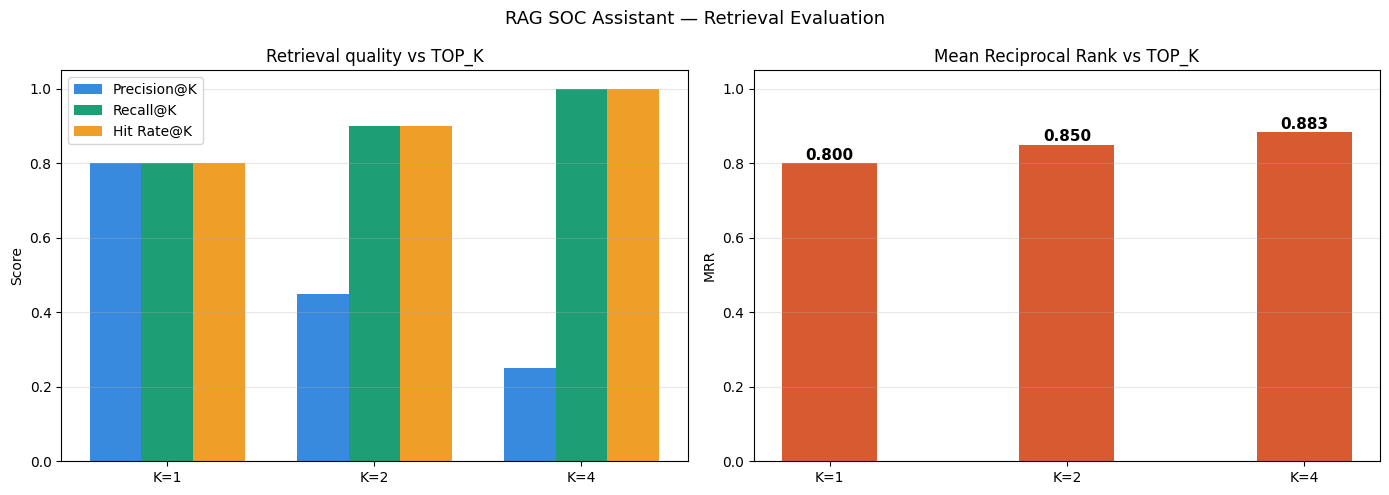

Saved: eval/retrieval_metrics.png


In [3]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_ks = [1, 2, 4]
bar_w  = 0.25
x      = np.arange(len(top_ks))

# Precision and Recall
ax = axes[0]
p_vals = [results[k].get(f'P@{k}', 0) for k in top_ks]
r_vals = [results[k].get(f'R@{k}', 0) for k in top_ks]
h_vals = [results[k].get(f'Hit@{k}', 0) for k in top_ks]

ax.bar(x - bar_w, p_vals, bar_w, label='Precision@K', color='#378ADD')
ax.bar(x,         r_vals, bar_w, label='Recall@K',    color='#1D9E75')
ax.bar(x + bar_w, h_vals, bar_w, label='Hit Rate@K',  color='#EF9F27')
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in top_ks])
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Retrieval quality vs TOP_K')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# MRR (same for all K since it's query-level)
ax2 = axes[1]
mrr_vals = [results[k]['MRR'] for k in top_ks]
ax2.bar([f'K={k}' for k in top_ks], mrr_vals, color='#D85A30', width=0.4)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('MRR')
ax2.set_title('Mean Reciprocal Rank vs TOP_K')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(mrr_vals):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('RAG SOC Assistant — Retrieval Evaluation', fontsize=13)
plt.tight_layout()
plt.savefig('../eval/retrieval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eval/retrieval_metrics.png')

In [4]:
# Per-alert breakdown at TOP_K=2 — identify failure cases
print('── Per-alert at TOP_K=2 ──────────────────────────────────────────────')
print(f'{"ID":<8} {"Hit?":<6} {"Retrieved":<25} {"Expected"}')
print('-' * 72)
for s in labels:
    retrieved = [h['id'] for h in rag.retrieve(s['alert'], collection, top_k=2)]
    expected  = s['ground_truth_playbook_ids']
    hit       = any(r in expected for r in retrieved)
    marker    = '✓' if hit else '✗'
    print(f"{s['id']:<8} {marker:<6} {str(retrieved):<25} {expected}")

── Per-alert at TOP_K=2 ──────────────────────────────────────────────
ID       Hit?   Retrieved                 Expected
------------------------------------------------------------------------
ta-001   ✓      ['pb-001', 'pb-013']      ['pb-001']
ta-002   ✓      ['pb-002', 'pb-008']      ['pb-002']
ta-003   ✓      ['pb-003', 'pb-013']      ['pb-003']
ta-004   ✓      ['pb-004', 'pb-015']      ['pb-004']
ta-005   ✓      ['pb-005', 'pb-019']      ['pb-005']
ta-006   ✓      ['pb-006', 'pb-020']      ['pb-006']
ta-007   ✓      ['pb-007', 'pb-001']      ['pb-007']
ta-008   ✓      ['pb-008', 'pb-002']      ['pb-008']
ta-009   ✓      ['pb-009', 'pb-012']      ['pb-009']
ta-010   ✓      ['pb-010', 'pb-005']      ['pb-010']
ta-011   ✗      ['pb-001', 'pb-013']      ['pb-011']
ta-012   ✓      ['pb-012', 'pb-005']      ['pb-012']
ta-013   ✓      ['pb-001', 'pb-013']      ['pb-013']
ta-014   ✓      ['pb-014', 'pb-005']      ['pb-014']
ta-015   ✓      ['pb-012', 'pb-015']      ['pb-015']
ta-016   ✓